In [107]:
import pandas as pd
import matplotlib.pyplot as plt

# Set the font
from matplotlib import font_manager as fm
fpath = "Microsoft Aptos Fonts/Aptos.ttf"
prop = fm.FontProperties(fname=fpath)
#plt.rcParams['font.family'] = 'Aptos'

from matplotlib.ticker import FuncFormatter

In [79]:
filepath = (
    'data/API_NY.GDP.PCAP.KD_DS2_en_csv_v2_82' 
    + '/API_NY.GDP.PCAP.KD_DS2_en_csv_v2_82.csv'
)


filepath = (
    'data/API_NY.GDP.PCAP.KD.ZG_DS2_en_csv_v2_391' 
    + '/API_NY.GDP.PCAP.KD.ZG_DS2_en_csv_v2_391.csv'
)

gdp_capita_df = pd.read_csv(filepath, skiprows=4)
gdp_capita_df.columns = [
    int(col) if col.isdigit() else col
    for col in gdp_capita_df.columns
]

The definitions of Asia-Pacific countries and Emerging Markets came from [ChatGPT](https://chatgpt.com/share/69a6404f-37a4-8012-a466-74dfeb9b1818)

In [80]:
# The definitions of Asia-Pacific countries and Emerging Markets came from ChatGPT
asia_pacific = [
    # East Asia
    "China", "Japan", "South Korea", "Mongolia", "Taiwan",
    
    # Southeast Asia
    "Philippines", "Indonesia", "Malaysia", "Thailand", "Vietnam",
    "Singapore", "Cambodia", "Laos", "Myanmar", "Brunei", "Timor-Leste",
    
    # South Asia
    "India", "Pakistan", "Bangladesh", "Sri Lanka", "Nepal",
    "Bhutan", "Maldives", "Afghanistan",
    
    # Oceania
    "Australia", "New Zealand", "Papua New Guinea", "Fiji",
    "Solomon Islands", "Samoa", "Vanuatu", "Tonga",
    "Micronesia", "Palau", "Kiribati", "Nauru", "Marshall Islands"
]

emerging_markets = [
    # Asia
    "China", "India", "Indonesia", "Philippines", "Thailand",
    "Vietnam", "Malaysia", "Pakistan", "Bangladesh",
    "Sri Lanka", "Mongolia",

    # Latin America
    "Brazil", "Mexico", "Argentina", "Chile",
    "Colombia", "Peru",

    # Emerging Europe
    "Poland", "Hungary", "Romania",
    "Czech Republic", "Turkey", "Ukraine",

    # Middle East & Africa
    "South Africa", "Egypt", "Nigeria", "Kenya",
    "Saudi Arabia", "Qatar", "United Arab Emirates"
]

In [102]:
# Define the dataframes and years to be plotted
asia_pacific_df = gdp_capita_df[gdp_capita_df['Country Name'].isin(asia_pacific)]
emerging_markets_df = gdp_capita_df[gdp_capita_df['Country Name'].isin(emerging_markets)]
philippines_df = asia_pacific_df[asia_pacific_df['Country Name'] == 'Philippines']

years = list((range(2005, 2025)))

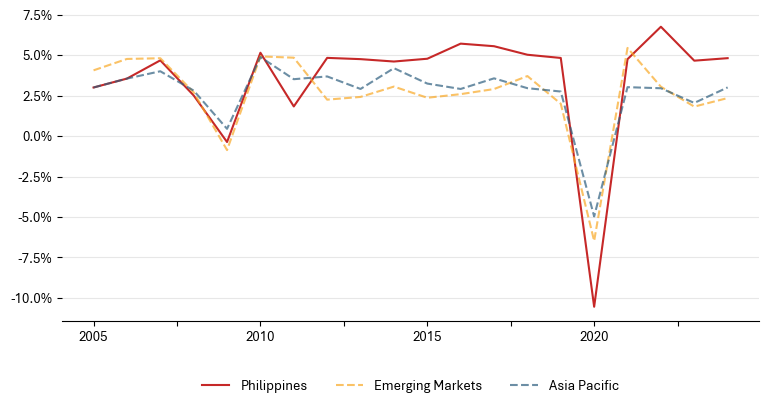

In [139]:
fig, ax = plt.subplots(figsize=(9, 4))
philippines_df[years].median().plot(kind='line', color='#C62828', ax=ax, label='Philippines')
emerging_markets_df[years].median().plot(kind='line', color='#F9A825', style='--', ax=ax, alpha=0.7, label='Emerging Markets')
asia_pacific_df[years].median().plot(kind='line', color='#2E5F7F', style='--', ax=ax, alpha=0.7, label='Asia Pacific')

# Remove the spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Clean the x axis
for tick in ax.get_xticklabels():
    tick.set_fontproperties(prop)
ax.xaxis.grid(False)

# Clean the y axis
for tick in ax.get_yticklabels():
    tick.set_fontproperties(prop)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x}%'))
ax.yaxis.grid(True, linestyle='-', alpha=0.3)

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False,
    fontsize=16,
    prop=prop
)

In [57]:
philippines_df

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
187,Philippines,PHL,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD,1123.7821,1150.629066,1168.608801,1211.8215,1214.709258,1241.109217,...,3247.450388,3410.93648,3575.881709,3198.6669,3350.975876,3577.701366,3744.697638,3925.30487,NaN,NaN
